## Model 2: Hierarchical table model (Stan)

**Idea:** same covariates as Model 1, but team skill combines long-run team quality and season-specific deviations, both measured **in points** (`tau_team`, `tau_season`).

**Backtest:** tables through 2024/25 → predict table 2025/26.

$$\text{Pts}_{s,t} \sim t_{\nu}\big(\alpha + \text{team\_skill}_{t} + \text{season\_dev}_{s,t} + \gamma^\top x_{s,t},\; \sigma_{\mathrm{pts}}\big)$$

with $x$ = (`sot_diff_pg`, `pts_lag1`, `ppg_last10`, z-scored) and $\sum_t \text{skill}_{s,t}=0$ per season.
Student-$t$ with $\nu=5$ fixed; $\tau_{\mathrm{team}}$ controls persistent team strength and $\tau_{\mathrm{season}}$ controls season-specific deviations.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
from cmdstanpy import CmdStanModel

import importlib
import helping_functions as hf
importlib.reload(hf)

from helping_functions import (
    load_matches,
    load_season_tables,
    prepare_table_stan_hierarchical,
    build_forecast_features,
    compute_table,
    predict_table,
    teams_in_season,
    STUDENT_T_NU,
    BACKTEST_TRAIN_SEASONS,
    BACKTEST_TEST_SEASON,
)


In [2]:
matches = load_matches()
TRAIN_SEASONS = BACKTEST_TRAIN_SEASONS
TEST_SEASON = BACKTEST_TEST_SEASON
LAST_TRAIN_SEASON = "2425"

tables = load_season_tables(matches, TRAIN_SEASONS)
stan_data, team_to_idx, train_teams, season_to_idx, feature_stats = (
    prepare_table_stan_hierarchical(tables, TRAIN_SEASONS)
)
stan_data["nu"] = STUDENT_T_NU
test_teams = sorted(teams_in_season(matches, TEST_SEASON))
last_season_idx = season_to_idx[LAST_TRAIN_SEASON]

print(f"Rows: {stan_data['N']}, seasons S={stan_data['S']}, teams T={stan_data['T']}")
print(f"Forecast uses season {LAST_TRAIN_SEASON} (index {last_season_idx})")


Rows: 320, seasons S=16, teams T=42
Forecast uses season 2425 (index 16)


### Prior selection (Model 2)

| Parameter | Prior | Expert rationale |
|-----------|-------|------------------|
| `intercept`, `beta_*` | as Model 1 | Mid-table baseline and process covariates |
| `log_sigma_pts` | $\mathcal{N}(\log 4.5, 0.12)$ | After skill + covariates, **unpredictable** season noise (injuries, luck) ≈ **4–6 pts** Student-$t$ scale |
| `log_tau_team` | $\mathcal{N}(\log 7, 0.20)$ | Persistent residual team-strength spread beyond process metrics |
| `log_tau_season` | $\mathcal{N}(\log 2.25, 0.18)$ | Small season-to-season deviations around long-run team strength |

Scale $0.18$ on log-scale ≈ ±20% — **informative** but not data-driven. Priors set **before** seeing the likelihood (domain knowledge only).

`skill[season, team] = team_skill[team] + season_dev[season, team]` on points scale; season deviations are sum-to-zero within each season.


In [3]:
model = CmdStanModel(stan_file="stan/table_hierarchical.stan")
fit = model.sample(
    data=stan_data,
    seed=42,
    chains=4,
    parallel_chains=4,
    iter_warmup=1500,
    iter_sampling=1500,
    adapt_delta=0.99,
    show_progress=True,
)
print(fit.diagnose())


15:01:42 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

15:01:49 - cmdstanpy - INFO - CmdStan done processing.



Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



### Sampling diagnostics

Check divergences (`fit.diagnose()` above), $\hat{R}$, and ESS.
Target: $\hat{R} \leq 1.01$, ESS bulk $\gtrsim 400$ per parameter.


                   Mean      MCSE     StdDev        MAD           5%  \
intercept     48.242600  0.013759   0.831105   0.834630    46.858800   
beta_sot       5.011410  0.012152   0.846318   0.840145     3.609360   
beta_lag       0.216738  0.005399   0.468179   0.462422    -0.544485   
beta_form      2.951820  0.012018   0.802746   0.793043     1.634880   
sigma_pts      7.482290  0.007719   0.411542   0.403067     6.802030   
tau_team       8.050960  0.021556   1.030260   1.026110     6.452680   
tau_season     2.694540  0.014448   0.599977   0.562120     1.869960   
lp__       -1066.820000  0.399241  15.659400  15.389400 -1092.560000   

                    50%          95%  ESS_bulk  ESS_tail    R_hat  
intercept     48.238200    49.608000   3651.26   4195.38  1.00013  
beta_sot       5.008170     6.383540   4861.44   4885.49  1.00070  
beta_lag       0.219475     0.991673   7589.98   4559.50  1.00052  
beta_form      2.960450     4.255190   4486.70   4473.61  1.00066  
sigma_pts  

,mean,sd,hdi_3%,hdi_97%,ess_bulk,ess_tail,r_hat
intercept,48.243,0.831,46.714,49.839,3651.0,4195.0,1.0
beta_sot,5.011,0.846,3.371,6.543,4861.0,4885.0,1.0
beta_lag,0.217,0.468,-0.675,1.064,7590.0,4560.0,1.0
beta_form,2.952,0.803,1.444,4.443,4487.0,4474.0,1.0
sigma_pts,7.482,0.412,6.682,8.247,2913.0,2733.0,1.0
tau_team,8.051,1.030,6.202,10.011,2295.0,3302.0,1.0
tau_season,2.695,0.600,1.715,3.826,2160.0,1774.0,1.0


Parameters with R-hat > 1.01: 0
Parameters with ESS_bulk < 400: 0


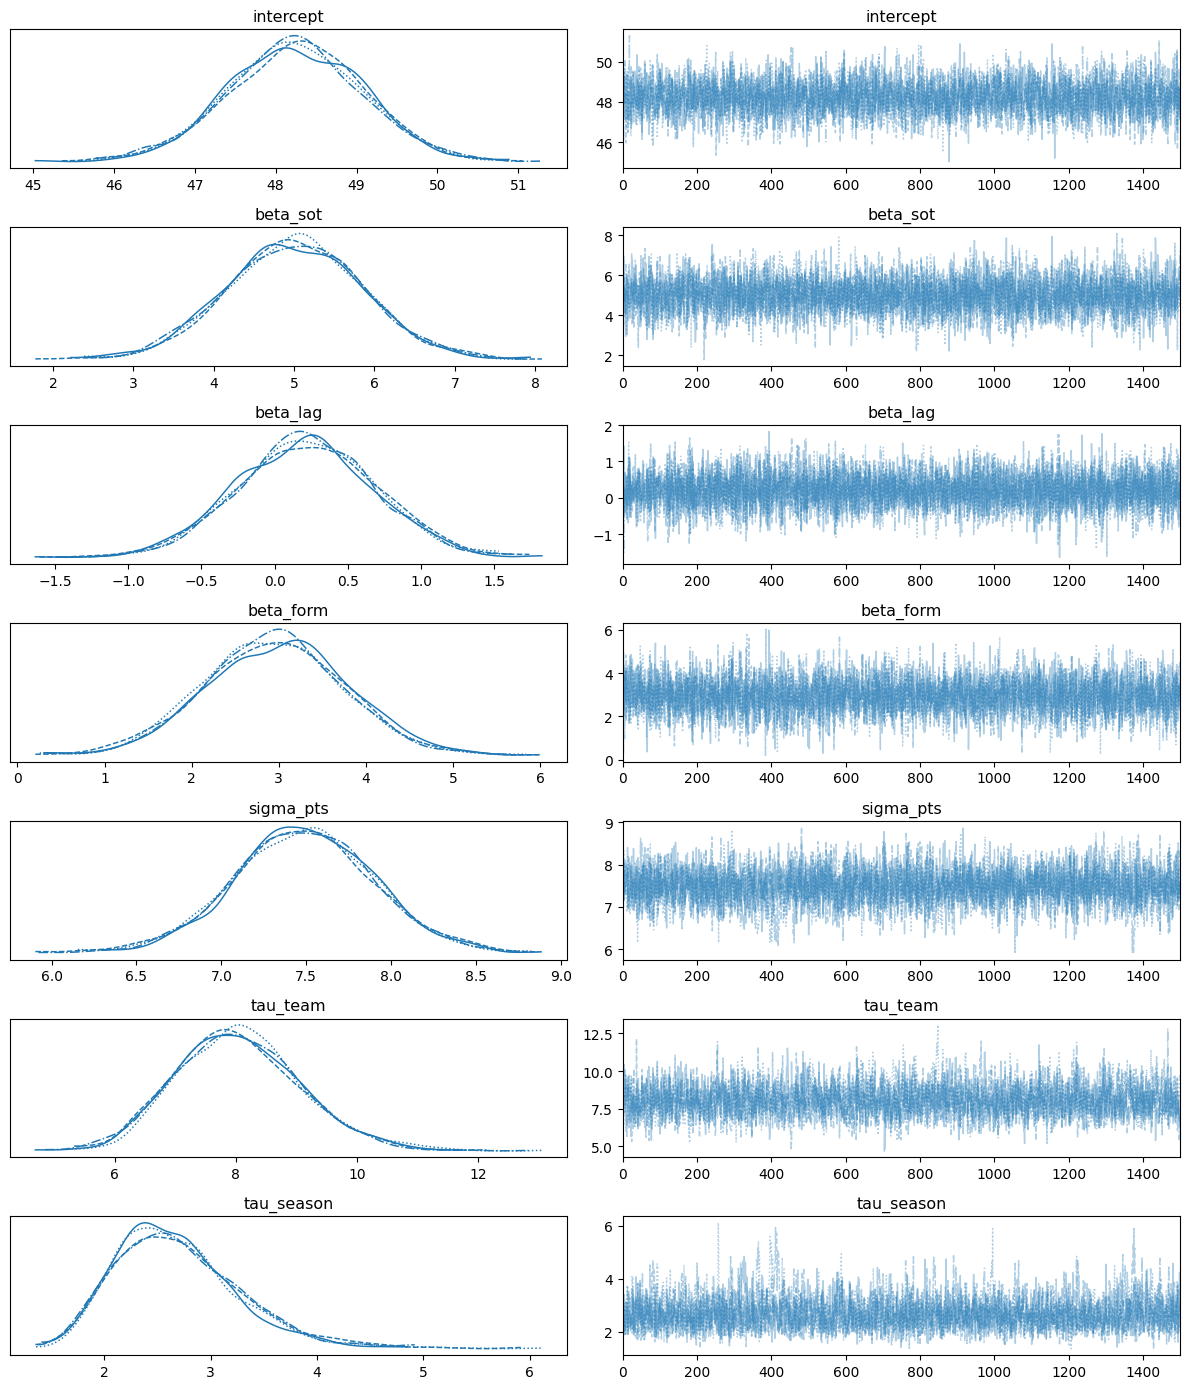

In [4]:
param_vars = [
    "intercept", "beta_sot", "beta_lag", "beta_form",
    "sigma_pts", "tau_team", "tau_season",
]
print(fit.summary().loc[param_vars + ["lp__"]])

idata = az.from_cmdstanpy(fit)
diag = az.summary(idata, var_names=param_vars)
cols = ["mean", "sd", "hdi_3%", "hdi_97%", "ess_bulk", "ess_tail", "r_hat"]
display(diag[cols])

bad_rhat = diag[diag["r_hat"] > 1.01]
low_ess = diag[diag["ess_bulk"] < 400]
print(f"Parameters with R-hat > 1.01: {len(bad_rhat)}")
if len(bad_rhat):
    display(bad_rhat[cols])
print(f"Parameters with ESS_bulk < 400: {len(low_ess)}")
if len(low_ess):
    display(low_ess[cols])

az.plot_trace(idata, var_names=param_vars, compact=True)
plt.tight_layout()
plt.show()


### Interpreting $\sigma_{\mathrm{pts}}$, $\tau_{\mathrm{skill}}$, and skills

| Parameter | Order of magnitude | Meaning |
|-----------|-------------------|---------|
| `tau_team` | ~6-10 pts | Persistent residual team quality beyond process metrics |
| `tau_season` | ~1.5-3 pts | Season-specific deviation around long-run team quality |
| `skill[s,t]` | +/-15-25 pts | Combined team + season deviation (in points) |
| `sigma_pts` | ~4-7 | Student-$t$ **scale** for leftover noise; approx. SD $\approx \sigma\sqrt{\nu/(\nu-2)}$ |

**Why $\sigma_{\mathrm{pts}} \ll 17$?** The value 17 is the **raw** SD of points in the table. Covariates and `skill` explain most of it; $\sigma_{\mathrm{pts}}$ is only irreducible season noise.


In [5]:
s_idx = last_season_idx - 1
skill_last = fit.stan_variable("skill")[:, s_idx, :].mean(axis=0)
idx_to_team = {i: t for t, i in team_to_idx.items()}

pd.DataFrame({
    "team": [idx_to_team[j+1] for j in range(len(skill_last))],
    "skill": skill_last,
}).sort_values("skill", ascending=False).head(10)


,team,skill
22,Man City,19.209090
20,Liverpool,14.778182
0,Arsenal,14.020529
23,Man United,13.649395
11,Chelsea,12.824782
36,Tottenham,10.905560
7,Brentford,4.279264
1,Aston Villa,4.018083
25,Newcastle,3.309422
13,Everton,2.201282


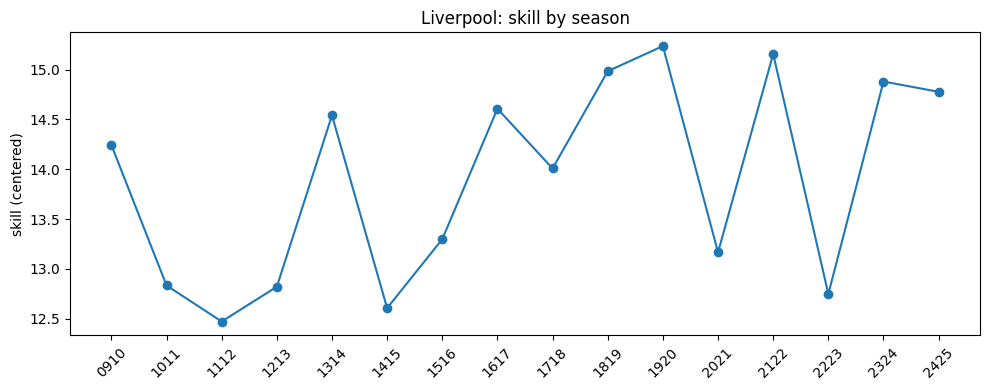

In [6]:
example_team = "Liverpool"
if example_team in team_to_idx:
    j = team_to_idx[example_team] - 1
    skill_ts = fit.stan_variable("skill")[:, :, j].mean(axis=0)
    seasons = list(season_to_idx.keys())
    plt.figure(figsize=(10, 4))
    plt.plot(seasons, skill_ts, marker="o")
    plt.xticks(rotation=45)
    plt.ylabel("skill (centered)")
    plt.title(f"{example_team}: skill by season")
    plt.tight_layout()
    plt.show()


### Posterior predictive check (PPC)

Simulate **replicated team-season points** from the posterior (Student-$t$ likelihood).
Compare the distribution and simple test statistics (mean, SD, min, max) to observed training points.
$p \approx 0.5$ suggests good calibration; values near 0 or 1 flag misfit.


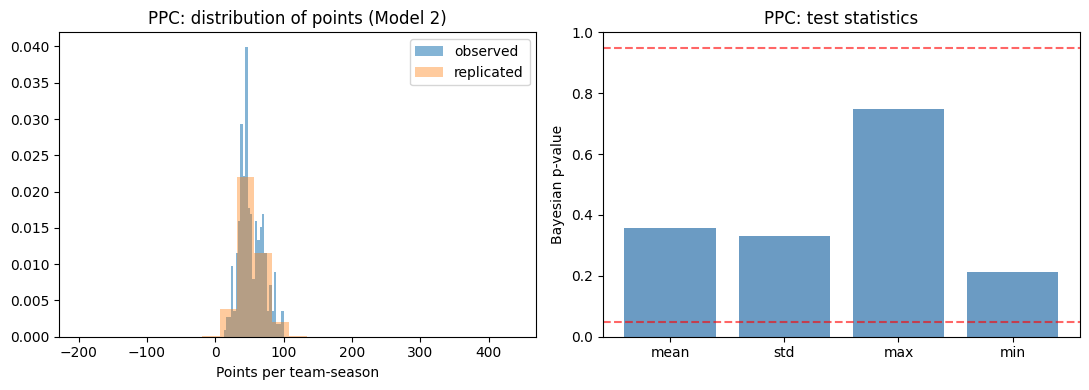

  mean: p = 0.357
  std: p = 0.332
  max: p = 0.748
  min: p = 0.213


In [7]:
from helping_functions import ppc_table_replicates

y_obs = stan_data["pts"]
y_rep = ppc_table_replicates(fit, stan_data, model="hierarchical")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(y_obs, bins=25, density=True, alpha=0.55, label="observed")
axes[0].hist(y_rep.reshape(-1), bins=25, density=True, alpha=0.4, label="replicated")
axes[0].set_xlabel("Points per team-season")
axes[0].set_title("PPC: distribution of points (Model 2)")
axes[0].legend()

stats = {"mean": np.mean, "std": np.std, "max": np.max, "min": np.min}
pvals = {}
for name, fn in stats.items():
    obs_val = fn(y_obs)
    rep_vals = fn(y_rep, axis=1)
    pvals[name] = float((rep_vals >= obs_val).mean())

axes[1].bar(pvals.keys(), pvals.values(), color="steelblue", alpha=0.8)
axes[1].axhline(0.05, color="red", ls="--", alpha=0.6)
axes[1].axhline(0.95, color="red", ls="--", alpha=0.6)
axes[1].set_ylim(0, 1)
axes[1].set_ylabel("Bayesian p-value")
axes[1].set_title("PPC: test statistics")
plt.tight_layout()
plt.show()

for name, p in pvals.items():
    print(f"  {name}: p = {p:.3f}")


**PPC interpretation (Model 2):** same logic as Model 1. If replicated points are too narrow/wide vs. observed, $\sigma_{\mathrm{skill}}$ or $\sigma_{\mathrm{pts}}$ may be mis-specified.


### Predict table 2025/26


In [8]:
forecast_features = build_forecast_features(
    matches, LAST_TRAIN_SEASON, test_teams, TRAIN_SEASONS, feature_stats
)

pred_table = predict_table(
    fit,
    test_teams,
    team_to_idx,
    model="hierarchical",
    last_season_index=last_season_idx,
    team_features=forecast_features,
    n_sims=500,
    seed=42,
)

actual = compute_table(matches, TEST_SEASON)[["team", "position", "Pts"]]
actual = actual.rename(columns={"position": "pos_actual", "Pts": "pts_actual"})

comparison = pred_table.merge(actual, on="team", how="left")
comparison["pos_error"] = comparison["pos_median"] - comparison["pos_actual"]
comparison.sort_values("pos_actual")


,team,pos_median,pos_mean,pts_median,pts_mean,pos_actual,pts_actual,pos_error
2,Arsenal,4.0,4.470,69.153432,69.287197,1,85,3.0
0,Man City,2.0,2.426,77.762436,78.147300,2,78,0.0
4,Man United,6.0,7.210,61.852712,61.647747,3,71,3.0
5,Aston Villa,8.5,9.326,56.707075,56.858526,4,65,4.5
1,Liverpool,3.0,3.742,71.776124,71.501709,5,60,-2.0
10,Bournemouth,13.0,12.696,50.042470,50.393318,6,57,7.0
12,Sunderland,14.0,13.542,47.543533,48.393267,7,54,7.0
7,Brighton,11.0,11.194,52.937892,53.087227,8,53,3.0
9,Brentford,12.0,11.828,52.146822,51.682644,9,53,3.0
3,Chelsea,4.0,4.904,67.747051,67.838170,10,52,-6.0


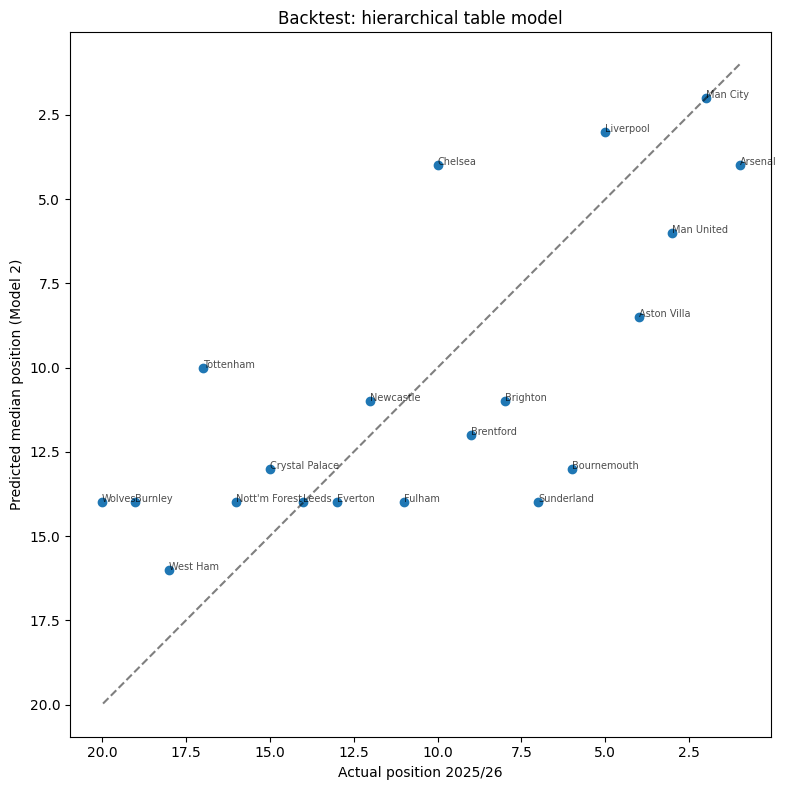

MAE position: 3.38


In [9]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(comparison["pos_actual"], comparison["pos_median"])
for _, r in comparison.iterrows():
    ax.annotate(r["team"], (r["pos_actual"], r["pos_median"]), fontsize=7, alpha=0.7)
ax.plot([1, 20], [1, 20], "k--", alpha=0.5)
ax.set_xlabel("Actual position 2025/26")
ax.set_ylabel("Predicted median position (Model 2)")
ax.set_title("Backtest: hierarchical table model")
ax.invert_xaxis()
ax.invert_yaxis()
plt.tight_layout()
plt.show()
print(f"MAE position: {comparison['pos_error'].abs().mean():.2f}")


### WAIC / LOO

Student-$t$ likelihood should lower Pareto $k$ for outlier team-seasons vs. Normal.  
Check `pareto_k`: values $\leq 0.7$ are reliable; $> 0.7$ = influential points.


In [10]:
idata = az.from_cmdstanpy(fit)
print(az.waic(idata))
loo = az.loo(idata, pointwise=True)
print(loo)

k = loo.pareto_k.values
n_good = int((k <= 0.7).sum())
n_bad = int(((k > 0.7) & (k <= 1)).sum())
n_very_bad = int((k > 1).sum())
print(f"\nPareto k: good (≤0.7) {n_good}/{len(k)} ({100 * n_good / len(k):.1f}%)")
print(f"           bad (0.7–1] {n_bad}, very bad (>1) {n_very_bad}")


Computed from 6000 posterior samples and 320 observations log-likelihood matrix.

          Estimate       SE
elpd_waic -1226.80    15.96
p_waic       69.87        -

There has been a warning during the calculation. Please check the results.


/usr/local/lib/python3.11/site-packages/arviz/stats/stats.py:1655: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


Computed from 6000 posterior samples and 320 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -1227.62    15.92
p_loo       70.69        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      320  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%


Pareto k: good (≤0.7) 320/320 (100.0%)
           bad (0.7–1] 0, very bad (>1) 0
